In [1]:
import numpy as np
from classy import Class
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from numpy.polynomial.legendre import legvander

In [2]:
cosmo = Class()

settings = {
    'output':'mPk',
    'non_linear':'oneloopPT',
    'has_rsd': 'yes',
    'fourier_verbose': 3,
    'ic':'ad',
    'accurate_lensing':1,
    'T_cmb':2.7255,
    'Omega_b':0.04886698938,
    'N_eff':3.046,
    'Omega_cdm':0.25929733618, # 0.11923 / h^2
    'YHe':0.24,
    'tau_reio':0.0568,
    'k_pivot':0.002,
    'A_s':2.08e-9,
    'n_s':0.97,
    'P_k_max_1/Mpc': 20,
    'z_max_pk':1.5,
    'z_pk': 0.,
    'h':0.7,
    'b1':1.,
    'b2':0.,
    'bG2':0.,
    'btd':0.,
    'cs2':0.0/0.67810**2,
    'R2':0./0.67810**2,
    'write_warnings':'yes'}

settings.update({'eft_verbose': 3,
                 'eft_compute_loop_matrices':'yes',
                 'eft_write_loop_matrices':'no',
                 'eft_direct_integration':'no'})

cosmo.set(settings)
z = np.array([0.1, 1.])

cosmo.compute(level=['background'])
D_A_fid = np.empty_like(z)
H_fid = np.empty_like(z)
for i,zz in enumerate(z):
            D_A_fid[i] = cosmo.angular_distance(zz) # in Mpc
            H_fid[i]   = cosmo.Hubble(zz)           # in (Mpc)^(-1)

settings.update({'h': 0.67})
cosmo.set(settings)
cosmo.compute()
D_A_true = np.empty_like(z)
H_true = np.empty_like(z)
for i,zz in enumerate(z):
            D_A_true[i] = cosmo.angular_distance(zz) # in Mpc
            H_true[i]   = cosmo.Hubble(zz)           # in (Mpc)^(-1)

ap_par  = H_fid/H_true      # 1/f_perp
ap_perp = D_A_true/D_A_fid  # = q_orth
ap_perp[(D_A_fid == 0.)] = 1.

print(ap_par)
print(ap_perp)

Computing linear Fourier spectra.
[1.0447744  1.04475673]
[1.04477528 1.04476748]
Computing nowiggle power spectra.
 -> sigma8=0.768723 for total matter (computed till k = 32.9221 h/Mpc)
Computing non-linear matter power spectrum at one loop including EFT terms (see arxiv:2402.09778) 
Generated 300 sample points for the linear power spectrum with
a base point density of 9.9 and of 79.0 per decade at the feature. 
Generated 300 sample points for the linear power spectrum with
a base point density of 9.2 and of 73.9 per decade at the feature. 
Generated 400 sample points for the linear power spectrum with
a base point density of 13.6 and of 109.1 per decade at the feature. 
Generated 200 sample points for the linear power spectrum with
a base point density of 16.3 and of 130.1 per decade at the feature. 
Could not insert loop matrices from external storage for index = 0: 
 => ext_insert_eft(L:139) :condition (index_eft >= pext->eft_size || pext->eft_index_num[index_eft] < num_matrices) i

In [3]:
mu_fid = np.linspace(-1., 1., num=500, endpoint=True)
k_fid = np.geomspace(1.e-3, 1., num=300, endpoint=True)

# this is k_obs[index_z, index_mu, index_k]
k_true = k_fid[None,None,:] / ap_perp[:,None,None] \
        * np.sqrt(1. + mu_fid[None,:,None]**2 * (((ap_perp/ap_par)**2)[:,None,None] - 1.))
# this is mu_obs[index_z, index_mu]
mu_true = mu_fid[None,:] * (ap_perp/ap_par)[:,None] / np.sqrt(1. + mu_fid[None,:]**2 * (((ap_perp/ap_par)**2)[:,None] - 1.))

In [4]:
bias = np.array([[2., -0.7, 0.2, 0.2], [1.5, -0.5, 0.15, 0.2]])
counter = np.array([[20., 10., 0., 10., 0., 5., 0.], [30., 10., 0., 10., 0., -5., 0.]])

In [5]:
pkl_class = cosmo.eft_pkl_rsd_grid(np.broadcast_to(k_fid, (len(z), len(k_fid))), z, ap_par, ap_perp, bias, counter, 'Pdd_hh_rsd')

index_pk_type = 0, index_tracer = 0, index_mu = 0: Performed Spline Fourier with bias -0.30 and relative power loss of 1.069e-09 at frequencies higher than 3.755e+01 
                                                      Fourier coefficients are bounded by 5.717e+05 / frequency^3 
index_pk_type = 0, index_tracer = 1, index_mu = 0: Performed Spline Fourier with bias -1.55 and relative power loss of 2.485e-07 at frequencies higher than 3.527e+01 
                                                      Fourier coefficients are bounded by 6.753e+04 / frequency^3 
index_pk_type = 1, index_tracer = 0, index_mu = 0: Performed Spline Fourier with bias -0.30 and relative power loss of 3.635e-12 at frequencies higher than 3.755e+01 
                                                      Fourier coefficients are bounded by 3.290e+04 / frequency^3 
index_pk_type = 1, index_tracer = 1, index_mu = 0: Performed Spline Fourier with bias -1.55 and relative power loss of 7.093e-13 at frequencies higher tha

In [6]:
deg = 4
pkmu = cosmo.eft_pkmu_rsd_grid(mu_true, k_true, z, bias, counter, 'Pdd_hh_rsd') # P(z, k_true, mu_true) as [index_z, index_mu, index_k]
legendre_poly = legvander(mu_fid, deg)[:, ::2]  # P_l(mu_fid) with [index_mu, index_l]
prefactor = (2.*np.arange(deg+1, step=2) + 1.)/2.
pkl_numerical = prefactor[None, :, None] * simpson(pkmu[:, :, None, :] * legendre_poly[None, :, :, None], x=mu_fid, axis=1) / (ap_par*ap_perp*ap_perp)[:,None,None]

In [7]:
from numpy.polynomial import legendre as lg

def gauss_lobatto_abscissas_and_weights(order):
    c = np.zeros(order, dtype='float64')
    c[order-1] = 1.     # P_{n-1}
    cder =  lg.legder(c) # P'_{n-1}
    glroots = np.zeros(order, dtype='float64')
    glroots[0] = -1.    # outer abscissas are fixed 
    glroots[-1] = 1.    # in Gauss-Lobatto rules
    # compute the inner abscissas as P'_{n-1}(x_i) = 0
    glroots[1:-1] = lg.legroots(cder)
    # compute the integration weights as 2/(n(n-1) P_{n-1}(x_i)^2)
    weights = 2./(order*(order-1) * lg.legval(glroots, c)**2)
    return glroots, weights

def gauss_legendre_abscissas_and_weights(order):
    c = np.zeros(order+1, dtype='float64')
    c[order] = 1.     # P_{n}
    # compute the inner abscissas as P_{n}(x_i) = 0
    glroots = lg.legroots(c)
    # compute the integration weights as 2/((1 - x_i^2) P'_{n}(x_i)^2)
    cder =  lg.legder(c) # P'_{n}
    weights = 2./((1 - glroots**2) * lg.legval(glroots, cder)**2)
    return glroots, weights

In [8]:
glorder = 9
mu_fid, weights = gauss_lobatto_abscissas_and_weights(glorder)
# this is k_obs[index_z, index_mu, index_k]
k_true = k_fid[None,None,:] / ap_perp[:,None,None] \
        * np.sqrt(1. + mu_fid[None,:,None]**2 * (((ap_perp/ap_par)**2)[:,None,None] - 1.))
# this is mu_obs[index_z, index_mu]
mu_true = mu_fid[None,:] * (ap_perp/ap_par)[:,None] / np.sqrt(1. + mu_fid[None,:]**2 * (((ap_perp/ap_par)**2)[:,None] - 1.))

In [9]:
# symmetrization
if (np.mod(glorder, 2) == 0):
  sym_weights = 2.*weights[int(glorder/2):]
else:
  sym_weights = 2.*weights[int((glorder-1)/2.):]
  sym_weights[0] = weights[int((glorder-1)/2.)]

print(mu_fid[int(np.ceil((glorder-1)/2.)):])
print(sym_weights)

[1.51860976e-16 3.63117464e-01 6.77186280e-01 8.99757995e-01
 1.00000000e+00]
[0.37151927 0.69285702 0.54907743 0.33099072 0.05555556]


In [10]:
pkmu = cosmo.eft_pkmu_rsd_grid(mu_true, k_true, z, bias, counter, 'Pdd_hh_rsd') # P(z, k_true, mu_true) as [index_z, index_mu, index_k]
legendre_poly = legvander(mu_fid, deg)[:, ::2]  # P_l(mu_fid) with [index_mu, index_l]
prefactor = (2.*np.arange(deg+1, step=2) + 1.)/2.
pkl_gl = prefactor[None, :, None] * np.sum(pkmu[:, :, None, :] * legendre_poly[None, :, :, None] * weights[None, :, None, None], axis=1) / (ap_par*ap_perp*ap_perp)[:,None,None]

/tmp/pa976791/login23-4_20097/ipykernel_21707/4098713610.py:10: RuntimeWarning: invalid value encountered in true_divide
  axd.plot(k_fid, (pkl_numerical[index_z,0] - pkl_class[index_z,0])/pkl_numerical[index_z,0], color = "red", label = "Monopole")
/tmp/pa976791/login23-4_20097/ipykernel_21707/4098713610.py:11: RuntimeWarning: invalid value encountered in true_divide
  axd.plot(k_fid, (pkl_numerical[index_z,1] - pkl_class[index_z,1])/pkl_numerical[index_z,1], color = "magenta", label = "Quadrupole")
/tmp/pa976791/login23-4_20097/ipykernel_21707/4098713610.py:12: RuntimeWarning: invalid value encountered in true_divide
  axd.plot(k_fid, (pkl_numerical[index_z,2] - pkl_class[index_z,2])/pkl_numerical[index_z,2], color = "orange", label = "Hexadecapole")


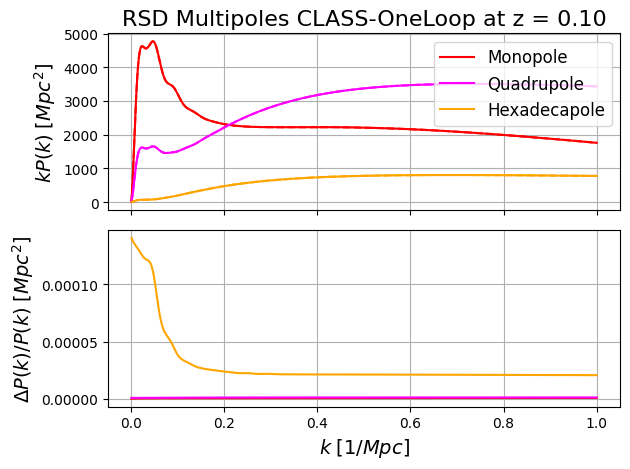

In [11]:
index_z = 0
fig, (axf, axd) = plt.subplots(2, 1, sharex=True)
axf.plot(k_fid, pkl_numerical[index_z,0]*k_fid, color = "red", label = "Monopole")
axf.plot(k_fid, pkl_class[index_z,0]*k_fid, color = "red", ls='--')
axf.plot(k_fid, pkl_numerical[index_z,1]*k_fid, color = "magenta", label = "Quadrupole")
axf.plot(k_fid, pkl_class[index_z,1]*k_fid, color = "magenta", ls='--')
axf.plot(k_fid, pkl_numerical[index_z,2]*k_fid, color = "orange", label = "Hexadecapole")
axf.plot(k_fid, pkl_class[index_z,2]*k_fid, color = "orange", ls='--')

axd.plot(k_fid, (pkl_numerical[index_z,0] - pkl_class[index_z,0])/pkl_numerical[index_z,0], color = "red", label = "Monopole")
axd.plot(k_fid, (pkl_numerical[index_z,1] - pkl_class[index_z,1])/pkl_numerical[index_z,1], color = "magenta", label = "Quadrupole")
axd.plot(k_fid, (pkl_numerical[index_z,2] - pkl_class[index_z,2])/pkl_numerical[index_z,2], color = "orange", label = "Hexadecapole")

axd.set_xlabel(r'$k \; [1/Mpc]$', fontsize = 14)
axf.set_ylabel(r'$k P(k)\; [Mpc^2]$', fontsize = 14)
axd.set_ylabel(r'$\Delta P(k) / P(k)\; [Mpc^2]$', fontsize = 14)
#axd.set_ylim(-5e-5, 1e-5)

axf.set_title("RSD Multipoles CLASS-OneLoop at z = {0:.2f}".format(z[index_z]), fontsize=16)
axf.grid()
axd.grid()
axf.legend(fontsize = 12)
fig.tight_layout()

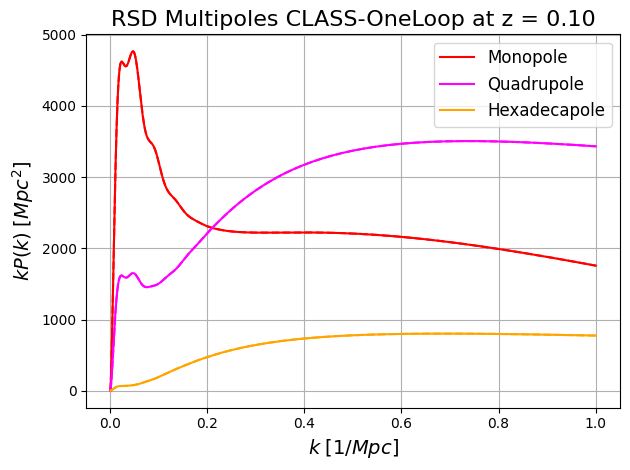

In [12]:
index_z = 0
plt.figure(1)
plt.plot(k_fid, pkl_numerical[index_z,0]*k_fid, color = "red", label = "Monopole")
plt.plot(k_fid, pkl_gl[index_z,0]*k_fid, color = "red", ls='--')
plt.plot(k_fid, pkl_numerical[index_z,1]*k_fid, color = "magenta", label = "Quadrupole")
plt.plot(k_fid, pkl_gl[index_z,1]*k_fid, color = "magenta", ls='--')
plt.plot(k_fid, pkl_numerical[index_z,2]*k_fid, color = "orange", label = "Hexadecapole")
plt.plot(k_fid, pkl_gl[index_z,2]*k_fid, color = "orange", ls='--')

plt.xlabel(r'$k \; [1/Mpc]$', fontsize = 14)
plt.ylabel(r'$k P(k)\; [Mpc^2]$', fontsize = 14)
#plt.xlim(1e-4, 0.5)

plt.title("RSD Multipoles CLASS-OneLoop at z = {0:.2f}".format(z[index_z]), fontsize=16)
plt.grid()
plt.legend(fontsize = 12)
plt.tight_layout()